# Get tcBF and acBF STEM image with GPU

**Before running the notebook, making sure to install the source code following the instruction in GitHub repo: https://github.com/chiahao3/fast-acbf**

> Note: This notebook is designed to demonstrate how to get tilt-corrected and aberration-corrected Bright-field STEM (tcBF and acBF) images from 4D-STEM data

Author: 
- Dr. Chia-Hao Lee , chia-hao.lee@cornell.edu

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
work_dir = "./" # Change the working directory if needed, but by default it's at the root level of this repo
os.chdir(work_dir)
print("Current working dir: ", os.getcwd())

Current working dir:  /home/cl2696/altas/workspace/fast-acbf


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from ptyrad.optics.constants import get_wavelength_ang
from ptyrad.io.generic import load_raw
from ptyrad.io.handlers import load_array_from_file
from ptyrad.runtime.diagnostics import print_system_info
from fast_acbf import BFSolver
from tifffile import imwrite

print_system_info()

### System information ###
Platform: Linux-6.8.0-101-generic-x86_64-with-glibc2.35
Operating System: Linux 6.8.0-101-generic
OS Version: #101~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Feb 11 13:19:54 UTC 
Machine: x86_64
Processor: x86_64
Available CPU cores: 32
Total Memory: 62.05 GB
Available Memory: 49.15 GB
 
### GPU information ###
CUDA Available: True
CUDA Version: 12.6
Available CUDA GPUs: ['NVIDIA RTX 5000 Ada Generation', 'NVIDIA RTX 5000 Ada Generation']
CUDA Compute Capability: ['8.9', '8.9']
  INFO: For torch.compile with Triton, you'll need CUDA GPU with Compute Capability >= 7.0.
        In addition, Triton does not directly support Windows.
        For Windows users, please follow the instruction and download `triton-windows` from https://github.com/woct0rdho/triton-windows.
MIG (Multi-Instance GPU) mode = False
  INFO: MIG splits a physical GPU into multiple GPU slices, but multiGPU does not support these MIG slices.
        In addition, multiGPU is currently only availabl

# Initialize dataset

In [21]:
# file_path = '/home/cl2696/scratch/20260412_Pt_at_HSC_Schuyler/07_3p6Mx_20pA_conv30_cl370_rt0_256_100us_df30.hdf5'

# dataset = load_array_from_file(file_path) # Loading this takes ~ 0.5 sec from local disk to RAM
# dataset = dataset.reshape(256,256,128,128)
# mean_DP = dataset.mean((0,1))
# dataset /= mean_DP.max() # Normalize such that PACBED has max intensity ~ 1

# kv = 300
# max_alpha = 30 # mrad
# defocus = -300 # Ang, positive is underfocs. Note that we can let AD refine this value later.
# scan_step_size = 0.594*2 # Ang
# Npix = 128
# dk = max_alpha * 1e-3 / 35.5 / get_wavelength_ang(kv) # Ang-1
# coord_transform={}

# ##====================================================

# cryoem_yue

# file_path = '/home/cl2696/scratch/cryoem_yue/14_scan_x256_y256.raw'

# dataset = load_raw(file_path, shape=(65536,128,128)) # Loading this takes ~ 0.5 sec from local disk to RAM
# dataset = dataset.reshape(256,256,128,128)
# mean_DP = dataset.mean((0,1))
# dataset /= mean_DP.max() # Normalize such that PACBED has max intensity ~ 1

# kv = 300
# max_alpha = 5.5 # mrad
# defocus = 0 # Ang, positive is underfocs. Note that we can let AD refine this value later.
# scan_step_size = 2.88 # Ang
# Npix = 128
# dk = max_alpha * 1e-3 / 43 / get_wavelength_ang(kv) # Ang-1
# coord_transform={}

# ##====================================================

# Single C1 atom
# file_path = '/home/cl2696/scratch/single_atom/20231128 C atom df -100 30 mrad 0.9Nyq sampling bin 4.h5'

# dataset = load_array_from_file(file_path) # Loading this takes ~ 0.5 sec from local disk to RAM
# dataset = dataset.reshape(204,204,85,85)[50:154, 50:154]
# mean_DP = dataset.mean((0,1))
# dataset /= mean_DP.max() # Normalize such that PACBED has max intensity ~ 1

# kv = 300
# max_alpha = 30 # mrad
# defocus = 0 # Ang, positive is underfocs. Note that we can let AD refine this value later.
# scan_step_size = 0.14778 # Ang
# Npix = 85
# dk = 30*2/0.9*1e-3 / get_wavelength_ang(kv) / Npix # Ang-1
# coord_transform={}

# ##====================================================

# Single A2 atom
file_path = '/home/cl2696/scratch/single_atom/C_atom_dim30x30A_p600_r0.15_ca30mrad_300kV_detector32mrad_C23_10000A_df_0A.h5'

dataset = load_array_from_file(file_path) # Loading this takes ~ 0.5 sec from local disk to RAM
dataset = dataset.reshape(200,200,166,166)[60:140,60:140]
mean_DP = dataset.mean((0,1))
dataset /= mean_DP.max() # Normalize such that PACBED has max intensity ~ 1

kv = 300
max_alpha = 30 # mrad
defocus = 0 # Ang, positive is underfocs. Note that we can let AD refine this value later.
scan_step_size = 0.15 # Ang
Npix = 166
dk = 32*2*1e-3 / get_wavelength_ang(kv) / Npix # Ang-1
coord_transform = {}

# ##====================================================

# tBL-WSe2
# file_path = '/home/cl2696/scratch/Figure 4/scan_x128_y128.raw'

# dataset = load_raw(file_path, shape=(16384,128,128)) # Loading this takes ~ 0.5 sec from local disk to RAM
# dataset = dataset.reshape(128,128,128,128)
# mean_DP = dataset.mean((0,1))
# dataset /= mean_DP.max() # Normalize such that PACBED has max intensity ~ 1

# kv = 80
# max_alpha = 25 # mrad
# defocus = -80 # Ang, positive is underfocs. Note that we can let AD refine this value later.
# scan_step_size = 0.43 # Ang
# Npix = 128
# dk = 0.0400 # Ang-1
# coord_transform = {'flipud': True}

# ##====================================================

# MOSS6
# file_path = '/home/cl2696/scratch/MOSS6/ExperimentalData_MOSS-6_Fig.3/scan_x256_y256.raw'

# dataset = load_raw(file_path, shape=(65536,128,128))
# dataset = dataset.reshape(256,256,128,128)
# dataset[dataset < 20] = 0 # Clip below 20
# mean_DP = dataset.mean((0,1))
# dataset /= mean_DP.max() # Normalize such that PACBED has max intensity ~ 1

# kv = 300
# max_alpha = 10 # mrad
# defocus = 885 # Ang, positive is underfocs
# scan_step_size = 1.051 # Ang
# Npix = 128
# dk = 0.0264 # Ang-1
# coord_transform = {'flipud': True}

##====================================================

# PSO
# file_path = '/home/cl2696/scratch/PSO/60_PSO_area9_41Mx_scan1_CL770mm_CA50um_21p4mrad_spot9_mono21p51_30pA_df20nm_50x_50y_100z_432step_x128_y128.raw'

# dataset = load_raw(file_path, shape=(16384,128,128)) # Loading this takes ~ 0.5 sec from local disk to RAM
# dataset = dataset.reshape(128,128,128,128)
# mean_DP = dataset.mean((0,1))
# dataset /= mean_DP.max() # Normalize such that PACBED has max intensity ~ 1

# kv = 300
# max_alpha = 21.4 # mrad
# defocus = -200 # Ang, positive is underfocs
# scan_step_size = 0.41 # Ang
# Npix = 128
# dk = 0.0417 # Ang-1
# coord_transform = {'transpose': True}

##====================================================

# tBL-STO
# file_path = '/home/cl2696/scratch/20240820_STO_bilayer_04_Hari/data_roi1_Ndp256_dp.hdf5'

# dataset = load_array_from_file(file_path, key='dp') # Loading this takes ~ 0.5 sec from local disk to RAM
# dataset = dataset.reshape(256,256,128,128)
# mean_DP = dataset.mean((0,1))
# dataset /= mean_DP.max() # Normalize such that PACBED has max intensity ~ 1

# kv = 300
# max_alpha = 30 # mrad
# defocus = -120 # Ang, positive is underfocs
# scan_step_size = 0.38595 # Ang
# Npix = 128
# dk = 0.0550 # Ang-1
# coord_transform = {}

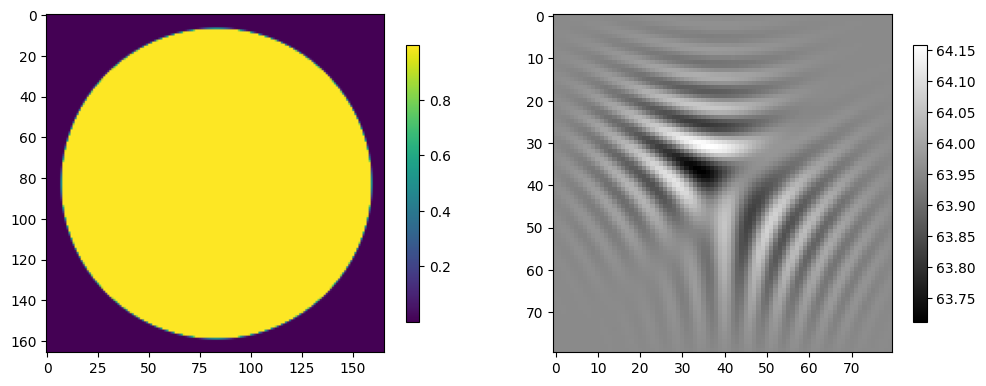

In [22]:

fig, axs = plt.subplots(1,2, figsize=(12,6))
im0 = axs[0].imshow(dataset.mean(axis=(0,1)))
im1 = axs[1].imshow(dataset[:,:,Npix//2-4:Npix//2+4,Npix//2-4:Npix//2+4].sum(axis=(-2,-1)), cmap='gray')
fig.colorbar(im0, shrink=0.6)
fig.colorbar(im1, shrink=0.6)
plt.show()

# Initialize BFSolver

`BFSolver` holds the 4D-dataset, and produces either tcBF or acBF, with flexible aberration refinement methods that can be chained together.

Extracted 19001 vBF images within the max alpha angle = 30 mrad.


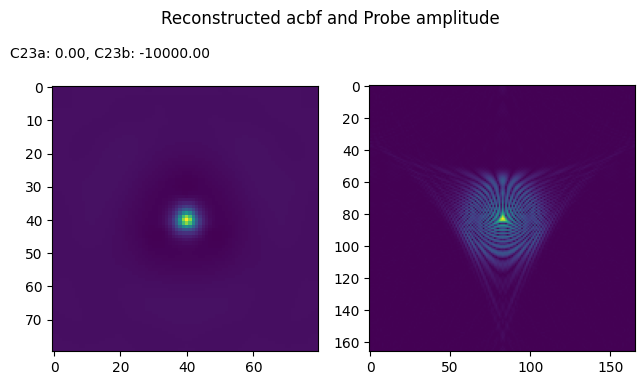

In [23]:
# Initialize the BFSolver takes ~ 0.3 sec, including sending vBF data to GPU
bf = BFSolver(dataset, 
              max_alpha=max_alpha, 
              scan_step_size=scan_step_size, 
              dk=dk, 
              wavelength=get_wavelength_ang(kv=kv), 
              max_order=2,
              aberrations={
                'C10': -defocus, #C10 is -df, positive C10 is overfocus 
                'C12': 0,
                'phi12': 0, 
                'C21': 00,
                'C23': 1e4,
                'phi23': 90
                }, 
              coord_transform = coord_transform,
              # coord_transform={
              #   'flipud': False,
              #   'rotation_deg': 0,
              # },
              device='cuda',
            )

# Plot the initial reconstruction without any refinement
# Calculation ~ 0.01 sec, but plotting takes ~ 0.3 - 0.6 sec
bf.plot_reconstruction(mode='acBF', upscale=1, output_frame='scan')

## Aberration Refinement

For optimal reconstruction quality, we can refine the initial aberrations.

`BFSolver` currently implements 2 refinement methods (API might change in the future):

- `.refine_defocus()`: Run a line search for defocus, very fast, good for quick initialization
- `.refine_aberrations()`: Run an AD optimization loop to refine aberrations to reach highest image quality

It's recommended to do a 2-stage approach as follows if you aren't sure about your initial defocus.

Starting defocus line search: 50 points between -500 and 500 Ang
Optimal C10 found at 112.24 Ang (max)


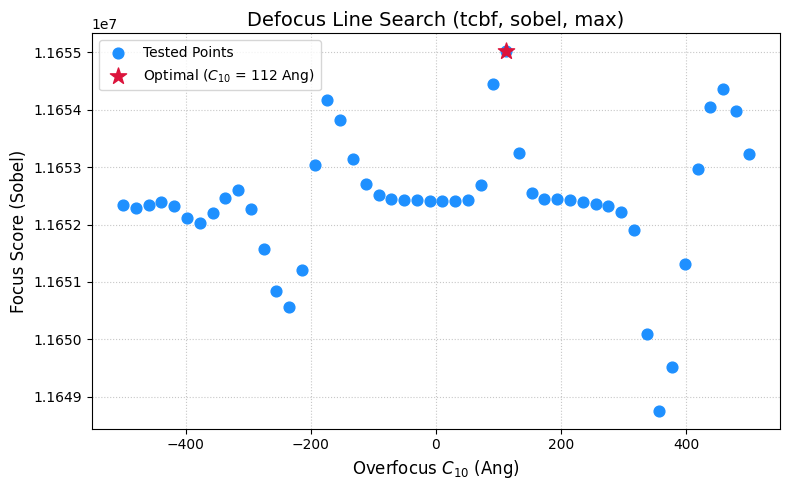

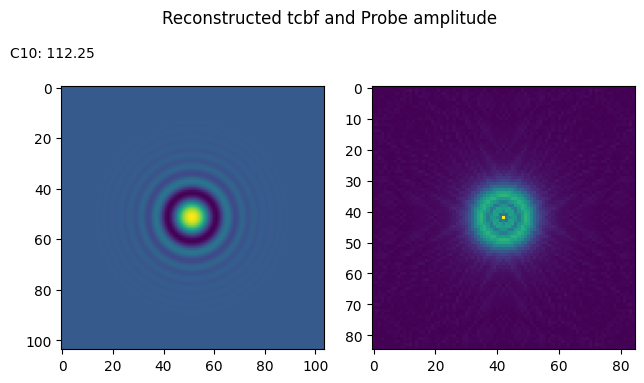

In [7]:
# Apply the defocus line search and plot the refined reconstruction
# Line searching 50 points of 681 images takes ~ 0.5 sec, plotting takes additional 0.3 sec
# Taking 5-10 points might be good enough for rough start
bf.refine_defocus(search_range=[-500, 500], 
                num_points=50, 
                metric='sobel', 
                method='max', 
                plot_line_search=True,
                mode='tcBF'
                )
bf.plot_reconstruction()

In [ ]:
# Furthe apply the AD-based aberration optimization and plot the refined reconstruction
# 1000 iterations takes 20 sec, with reasonable initial guess (and defocus line search) we may only need 50 iterations (~ 1 sec)

# You might want to manually play with learning rate (lr) and iterations (iter) for best result
# Also, refine_aberrations() is most stable in 'tcBF' mode, because acBF might introduces wild amplitude variations
# You can disable plotting for fastest throughput
bf.refine_aberrations(iters=101, lr=15, metric='normalized_std', plot_recon_every_n_iter=None, save_dir=None, mode='tcBF')

bf.print_aberrations()

bf.plot_reconstruction()

# Export 3D defocus stack

In [24]:
volume_tcbf    = bf.get_defocus_stack(mode='tcBF', n_layers=100, slice_thickness=10, upscale=1).detach().cpu().numpy()
volume_acbf    = bf.get_defocus_stack(mode='acBF', n_layers=100, slice_thickness=10, upscale=1).detach().cpu().numpy()
volume_acbf_ci = bf.get_defocus_stack(mode='acBF', n_layers=100, slice_thickness=10, upscale=1, acbf_algorithm='complex_inversion').detach().cpu().numpy()

imwrite('output/volume_tcbf.tif', np.float32(volume_tcbf))
imwrite('output/volume_acbf.tif', np.float32(volume_acbf))
imwrite('output/volume_acbf_ci.tif', np.float32(volume_acbf_ci))

# Visualize 3D defocus stack

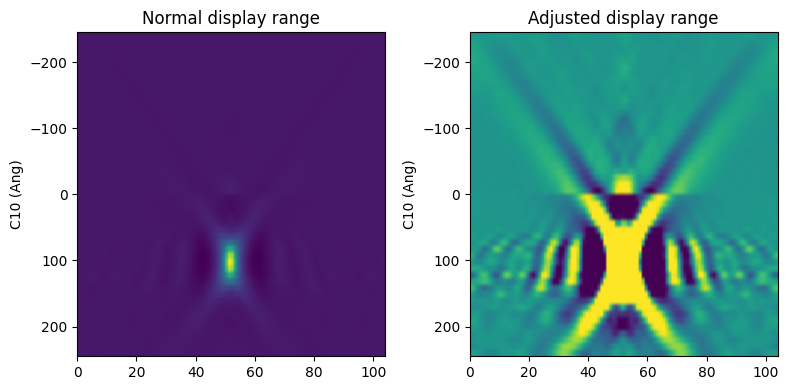

In [14]:
# Original acbf
stack = volume_acbf

shape = stack.shape
c10_axis_np = bf.last_c10_stack_axis.cpu().numpy()

vmin = np.percentile(stack, 1)
vmax = np.percentile(stack, 99)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].set_title('Normal display range')
axs[1].set_title('Adjusted display range')

image_extent = (0, shape[-1], c10_axis_np[-1], c10_axis_np[0])
im0 = axs[0].imshow(stack[:, shape[-2]//2], aspect='auto', extent=image_extent)
im1 = axs[1].imshow(stack[:, shape[-2]//2], aspect='auto', vmin=vmin, vmax=vmax, extent=image_extent)

axs[0].set_ylabel("C10 (Ang)")
axs[1].set_ylabel("C10 (Ang)")

# It's best practice to explicitly associate the colorbar with its axes.
# fig.colorbar(im0, ax=axs[0])
# fig.colorbar(im1, ax=axs[1])

# Adjust layout to prevent labels from overlapping.
plt.tight_layout()
plt.show()

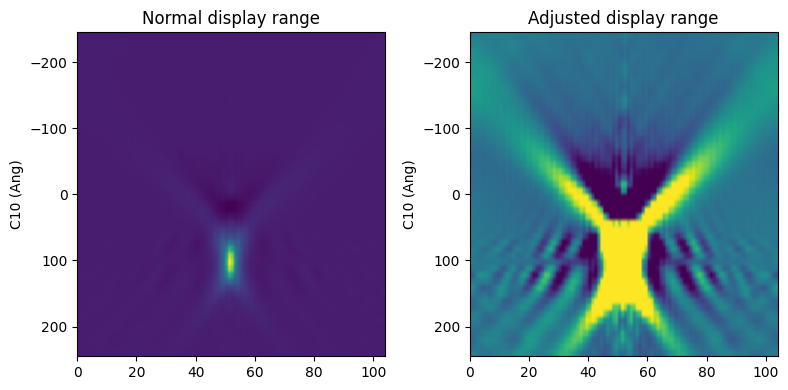

In [ ]:
# Contrast inversion acbf

stack = volume_acbf_ci

shape = stack.shape
c10_axis_np = bf.last_c10_stack_axis.cpu().numpy()

vmin = np.percentile(stack, 1)
vmax = np.percentile(stack, 99)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].set_title('Normal display range')
axs[1].set_title('Adjusted display range')

image_extent = (0, shape[-1], c10_axis_np[-1], c10_axis_np[0])
im0 = axs[0].imshow(stack[:, shape[-2]//2], aspect='auto', extent=image_extent)
im1 = axs[1].imshow(stack[:, shape[-2]//2], aspect='auto', vmin=vmin, vmax=vmax, extent=image_extent)

axs[0].set_ylabel("C10 (Ang)")
axs[1].set_ylabel("C10 (Ang)")

# It's best practice to explicitly associate the colorbar with its axes.
# fig.colorbar(im0, ax=axs[0])
# fig.colorbar(im1, ax=axs[1])

# Adjust layout to prevent labels from overlapping.
plt.tight_layout()
plt.show()

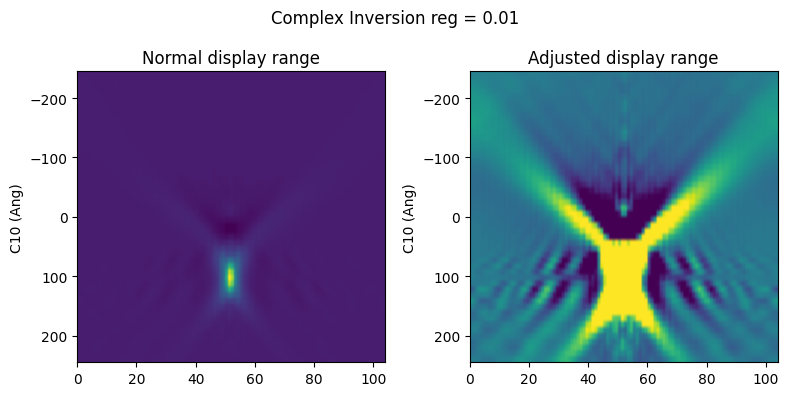

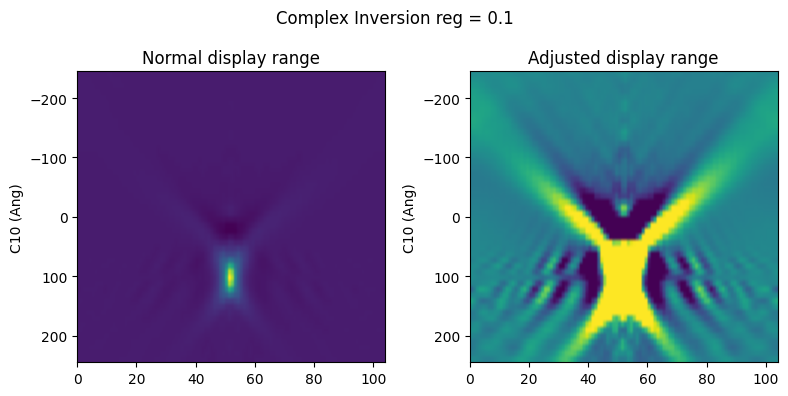

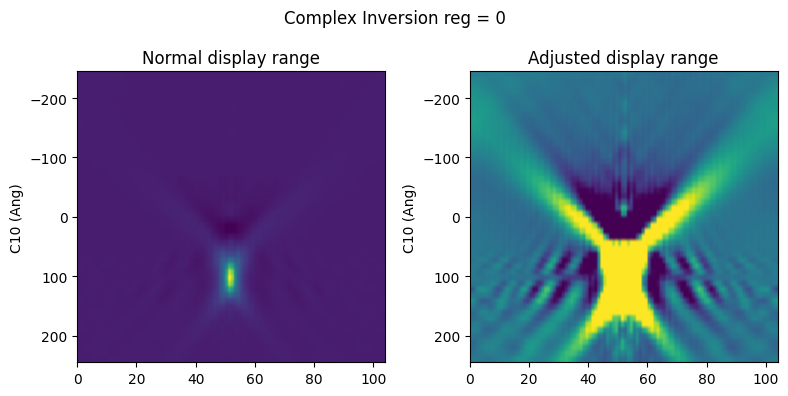

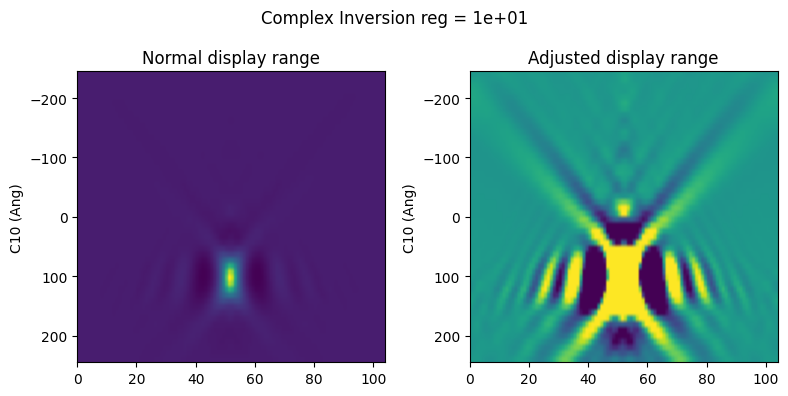

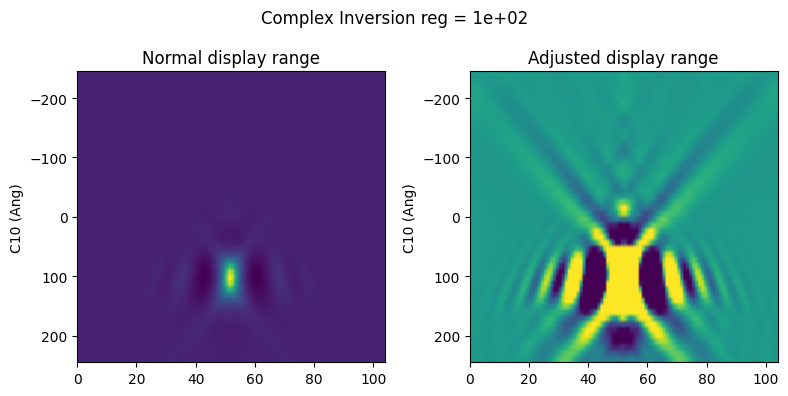

In [20]:
for reg in [1e-2, 1e-1, 0, 1e1, 1e2]:
    volume_acbf_ci = bf.get_defocus_stack(mode='acBF', n_layers=50, slice_thickness=10, upscale=1, acbf_algorithm='complex_inversion', regularization=reg).detach().cpu().numpy()


    stack = volume_acbf_ci

    shape = stack.shape
    c10_axis_np = bf.last_c10_stack_axis.cpu().numpy()

    vmin = np.percentile(stack, 1)
    vmax = np.percentile(stack, 99)

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(f'Complex Inversion reg = {reg:.1g}')
    axs[0].set_title('Normal display range')
    axs[1].set_title('Adjusted display range')

    image_extent = (0, shape[-1], c10_axis_np[-1], c10_axis_np[0])
    im0 = axs[0].imshow(stack[:, shape[-2]//2], aspect='auto', extent=image_extent)
    im1 = axs[1].imshow(stack[:, shape[-2]//2], aspect='auto', vmin=vmin, vmax=vmax, extent=image_extent)

    axs[0].set_ylabel("C10 (Ang)")
    axs[1].set_ylabel("C10 (Ang)")

    # It's best practice to explicitly associate the colorbar with its axes.
    # fig.colorbar(im0, ax=axs[0])
    # fig.colorbar(im1, ax=axs[1])

    # Adjust layout to prevent labels from overlapping.
    plt.tight_layout()
    plt.show()

## Timing code for dev purpose

In [ ]:
# Time the reconstruction time (i.e., shifting and summing all vBF images with optional CTF correction)
from ptyrad.solver.reconstruction import time_sync

repetition = 1000
total_t = 0
mode='tcBF'

for i in range(repetition):

    t0 = time_sync()
    bf.reconstruct(mode=mode, chunk_size=681, upscale=1)
    t1 = time_sync()
    
    total_t += (t1-t0)
print(f"Reconstructing {bf.bf_mask.sum()} vBF images in {mode} mode takes {total_t / repetition:.4f} sec")

# Plotting code for sanity check

In [ ]:
bf.plot_chi_surface(plot_probe_phase=True)

In [ ]:
bf.plot_shift_quiver();